## Using nuclei-binned data

Instead of running the analysis on 2um bins directly, we now use 2um bins that are aggregated on segmented nuclei.

In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../scripts/utils
import sys
sys.path.append('../scripts')
from utils import _rasterize_bins

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [ ]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3
sc.settings.figdir = "./plots"

In [2]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

In [10]:
adata = sdata.tables['table_002um_stardist_segmentation_pp']
labels_layer = "segmentation_mask"

## Cell type scoring

Since each nuclei is theoretically at 'single cell', let us try annotating these cells via marker gene scoring. We will do this using the marker genes from the single-cell atlas, filtered to top 50% marker genes.

In [11]:
# Use sparrow.tb.score_genes to score the marker genes in the adata
sp.tb.score_genes(sdata, labels_layer=labels_layer, table_layer="table_002um_stardist_segmentation_pp",
                  output_layer="table_002um_stardist_segmentation_q50_celltype_scores",
                  path_marker_genes='../data/liver_marker_genes/markers_mouseStStAll_onehot_q50.csv' , celltype_column='annotation',
                  overwrite=True)

       'Gm15675', 'Mmrn2', 'Nos3', 'Plet1os', 'Rps6ka2', 'Tmem2'],
      dtype='object')
       'Meg3', 'Nrxn3', 'Olfml3'],
      dtype='object')
       '4732465J04Rik', '5830473C10Rik', '9030616G12Rik', '9030622O22Rik',
       'AC118710.3', 'AC169509.3', 'Apol9b', 'B630019A10Rik', 'BC025446',
       'Cyp3a25', 'Gm10658', 'Gm11789', 'Gm16157', 'Gm16573', 'Gm20319',
       'Gm27216', 'Gm30262', 'Gm36264', 'Gm48633', 'Gm4952', 'H2-Q10',
       'Hnf1aos1', 'Hnf4aos', 'Mup11', 'Mup2', 'Mup21', 'Pbld1', 'Prox1os',
       'Serpina1e', 'Ttc36', 'Upp2'],
      dtype='object')
       '9030622O22Rik', '9130008F23Rik', '9530026P05Rik', 'Airn', 'C2cd4b',
       'Ccdc148', 'Ctgf', 'Cyr61', 'Fam213a', 'Fam84b', 'Hnf1aos1', 'Snhg18'],
      dtype='object')
       '9030622O22Rik', '9530026P05Rik', 'Cyp2s1', 'Eya2', 'Flrt3', 'Grip1',
       'Hnf1aos1', 'Pip5k1b', 'Styk1', 'Tenm1', 'Zfp239'],
      dtype='object')
       'Fam105a', 'Gm15987', 'Gm34084', 'Gm6377', 'Slc36a3os', 'Tnfrsf13b',
       'Tnfsf9

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

: 

In [8]:
sdata.tables['table_002um_stardist_segmentation_all_celltype_scores'].write_h5ad('table_002um_stardist_segmentation_all_celltype_scores.h5ad')

Unfortunately the results are super messy like this, 99% of the cells were annotated as hepatocytes!

In [7]:
# Get cell type proportions of the cells
sdata.tables['table_002um_stardist_segmentation_all_celltype_scores'].obs['annotation'].value_counts(normalize=True)

annotation
Hepatocytes                          0.993738
Cholangiocytes                       0.003870
Kupffercells                         0.000838
cDC1s                                0.000277
MigcDCs                              0.000263
MonocytesandMonocytesderivedcells    0.000241
HsPCs                                0.000241
Stromalcells                         0.000227
Endothelialcells                     0.000085
Bcells                               0.000078
cDC2s                                0.000043
NKcells                              0.000028
pDCs                                 0.000028
Basophils                            0.000014
ILC1s                                0.000014
Neutrophils                          0.000014
Name: proportion, dtype: float64

/tmp/ipykernel_19614/1181893103.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables[table_layer]


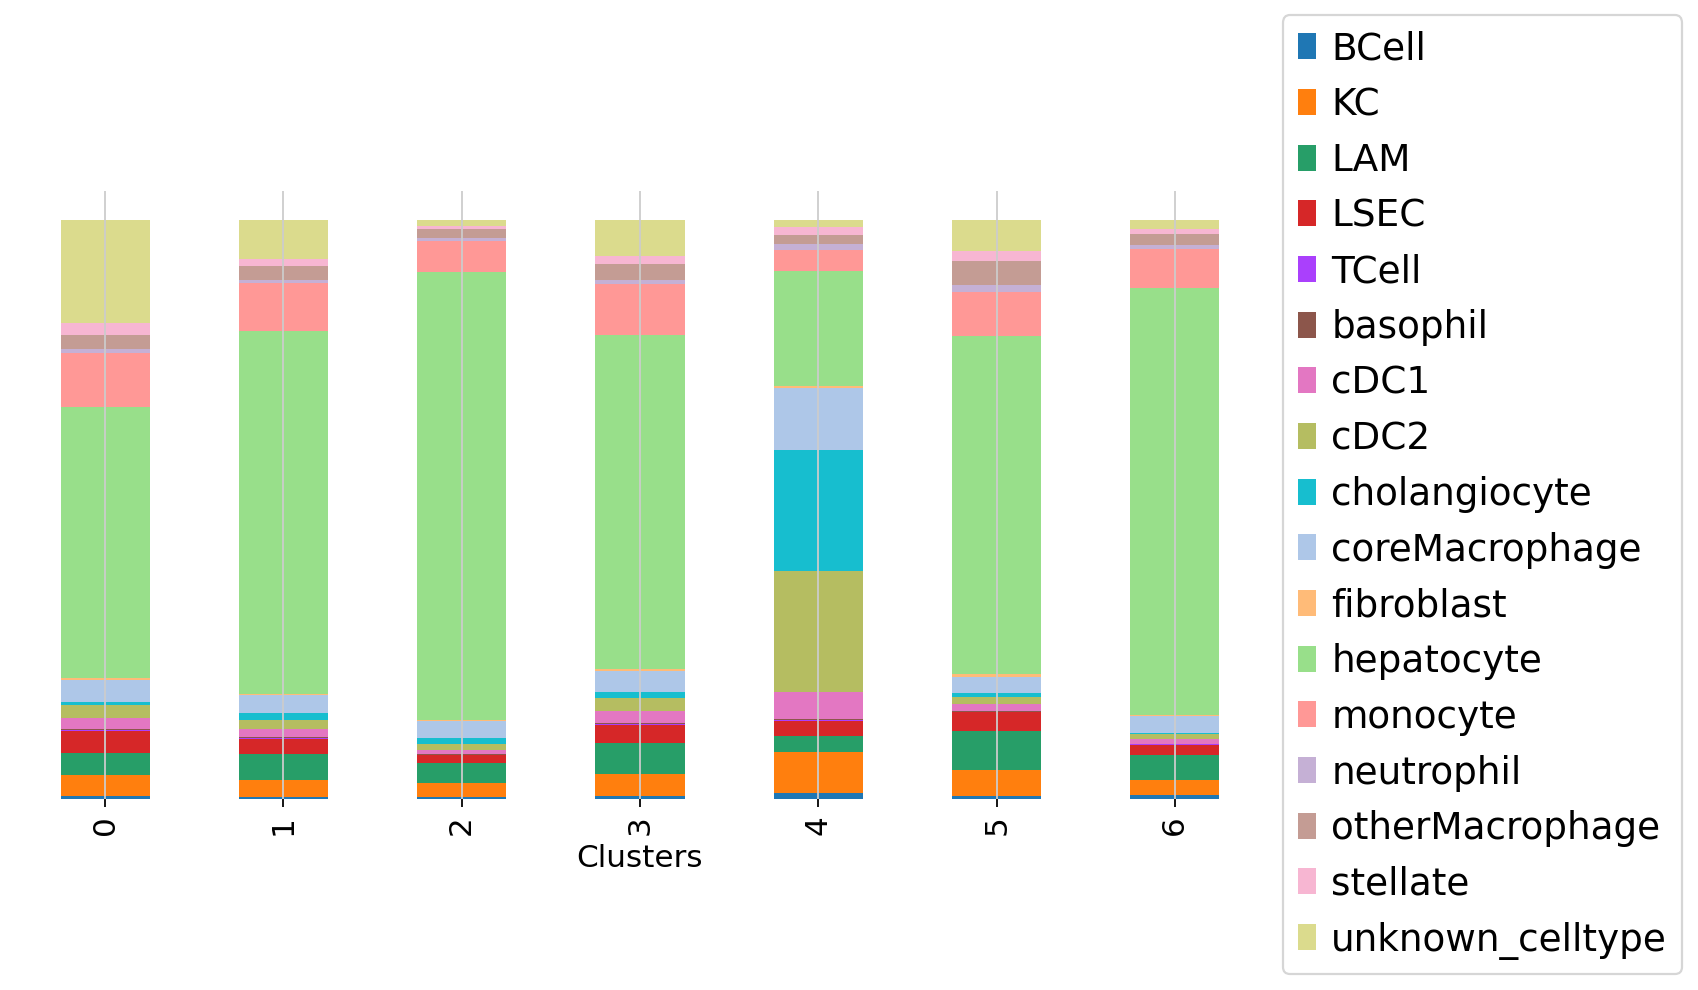

In [7]:
celltype_column = "annotation"
table_layer = "table_002um_stardist_segmentation_celltype_scores"
stacked = (
        sdata.tables[table_layer]
        .obs.groupby(["clusters", celltype_column], as_index=False)
        .size()
        .pivot(index="clusters", columns=celltype_column)
        .fillna(0)
    )
stacked_norm = stacked.div(stacked.sum(axis=1), axis=0)
stacked_norm.columns = list(sdata.tables[table_layer].obs[celltype_column].cat.categories)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

stacked_norm.plot(kind="bar", stacked=True, ax=fig.gca())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.get_yaxis().set_ticks([])
plt.xlabel("Clusters")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="large")

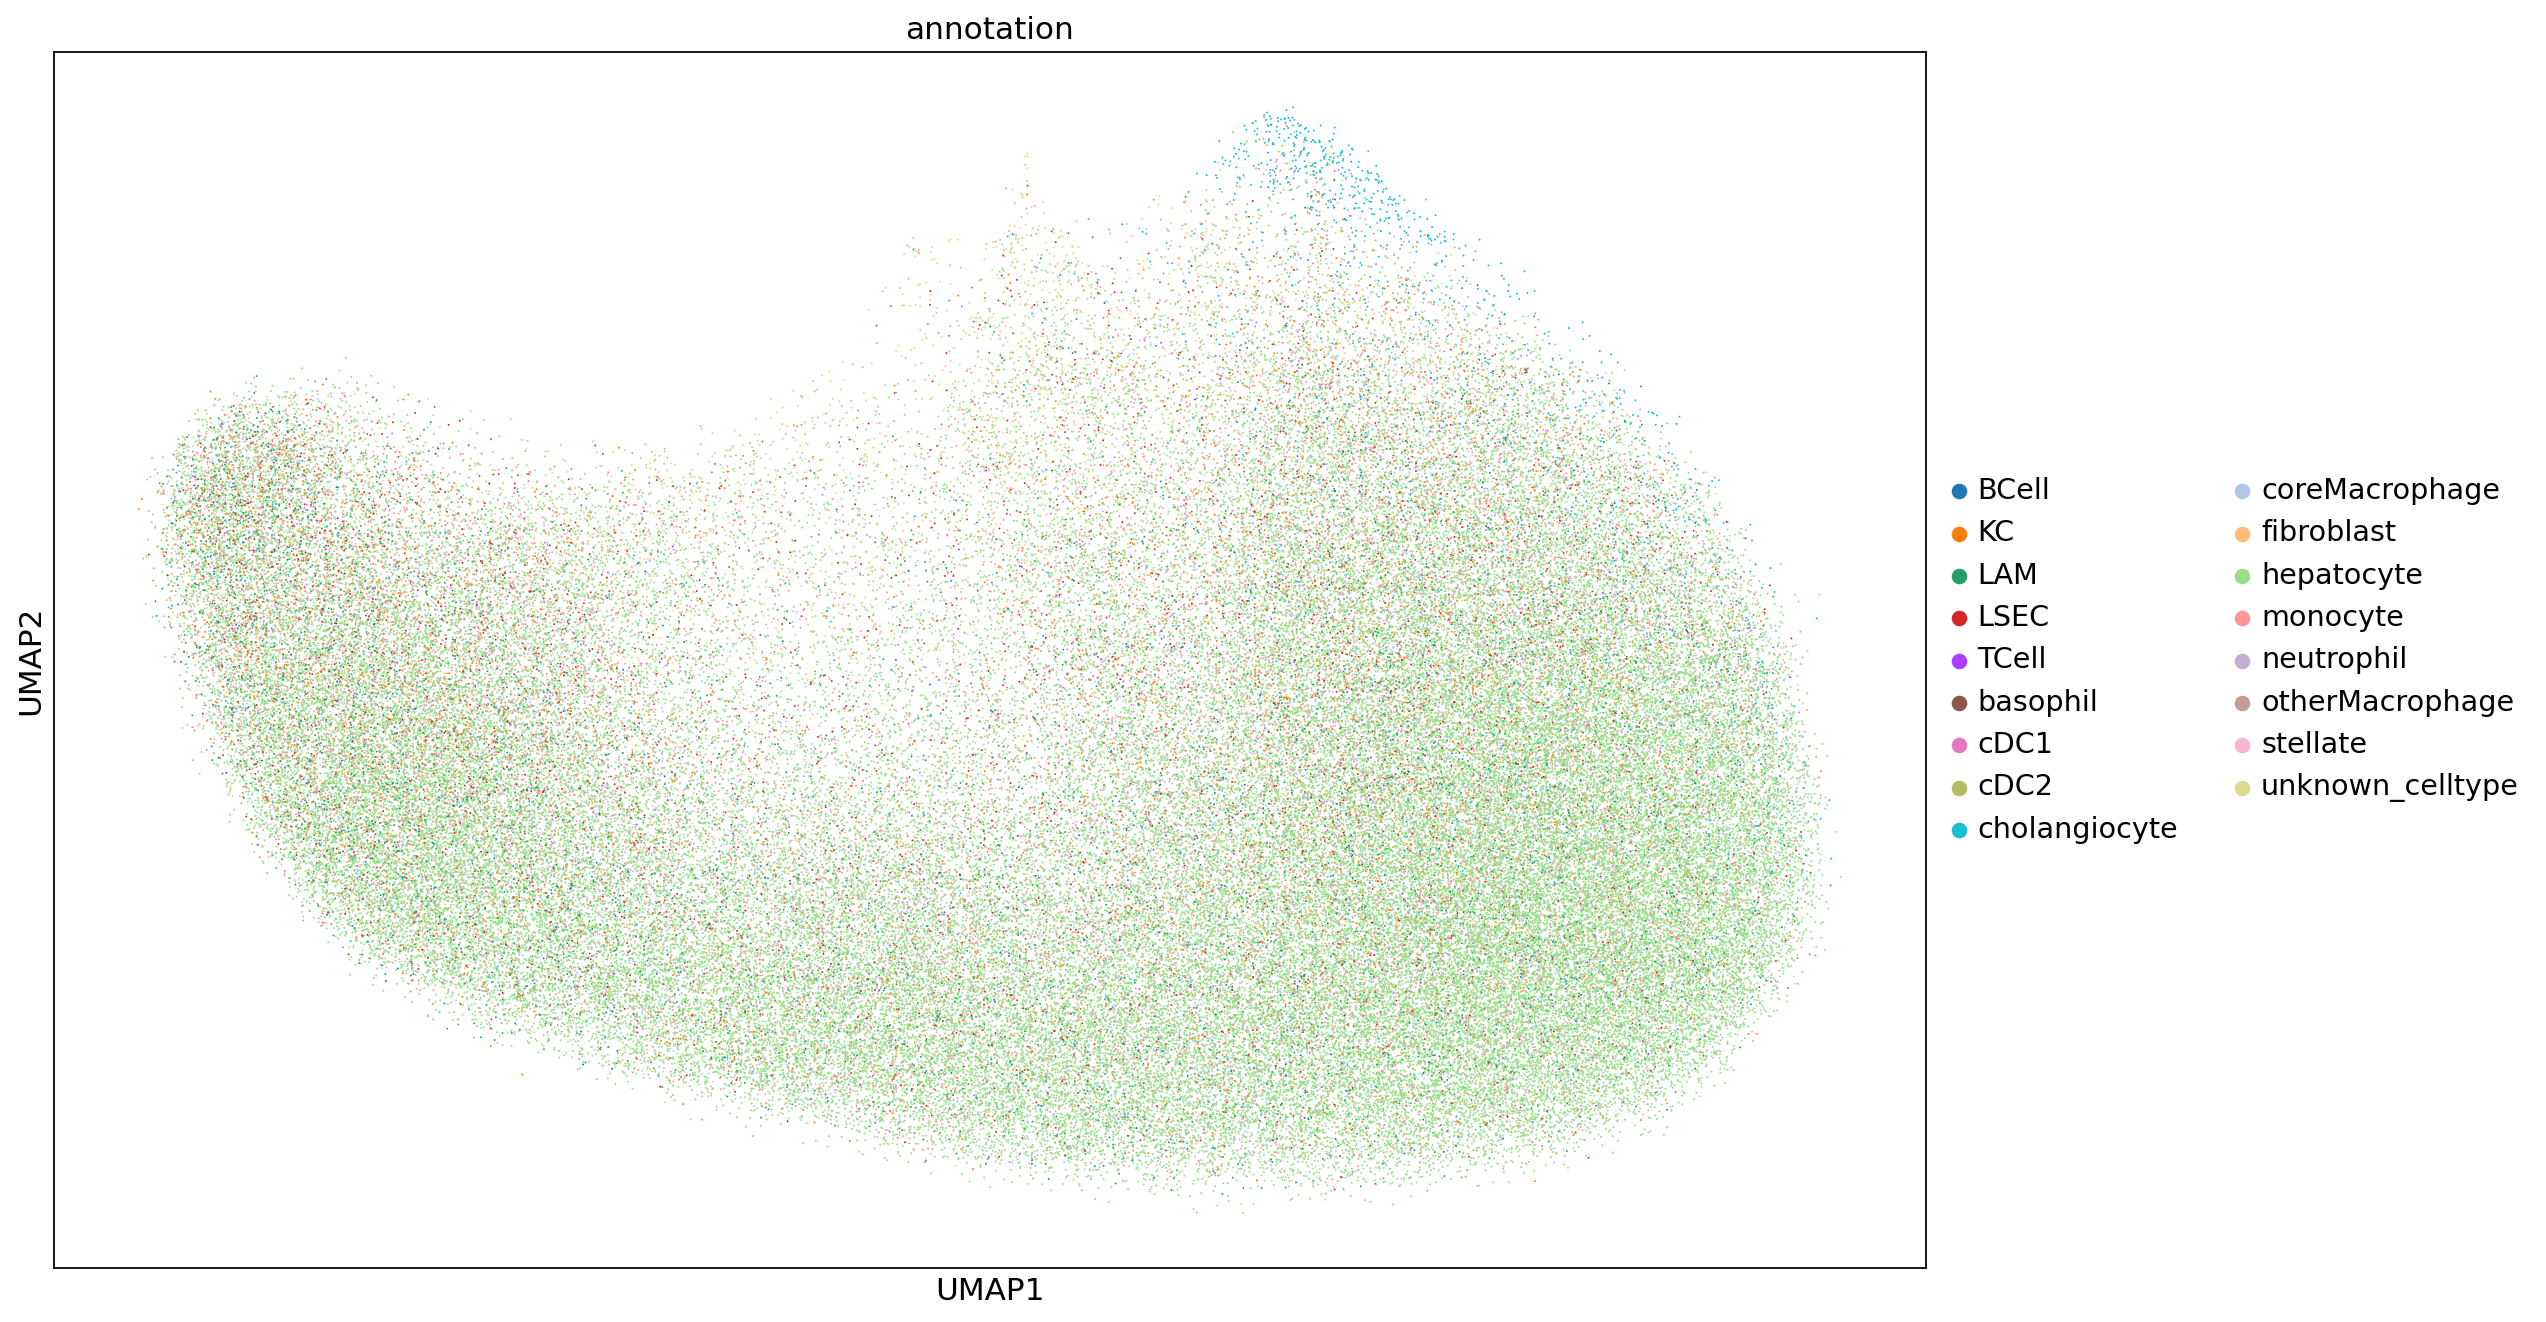

(-2.0433925926685332, 14.4084208548069, -9.028283039480447, 0.5359127469360829)

In [8]:
# UMAP plot with cells colored by cell type.
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
sc.pl.umap(
    sdata.tables[table_layer],
    color=[celltype_column],
    ax=ax,
    size=3,
)
ax.axis("off")


<Axes: xlabel='Cleanliness', ylabel='annotation'>

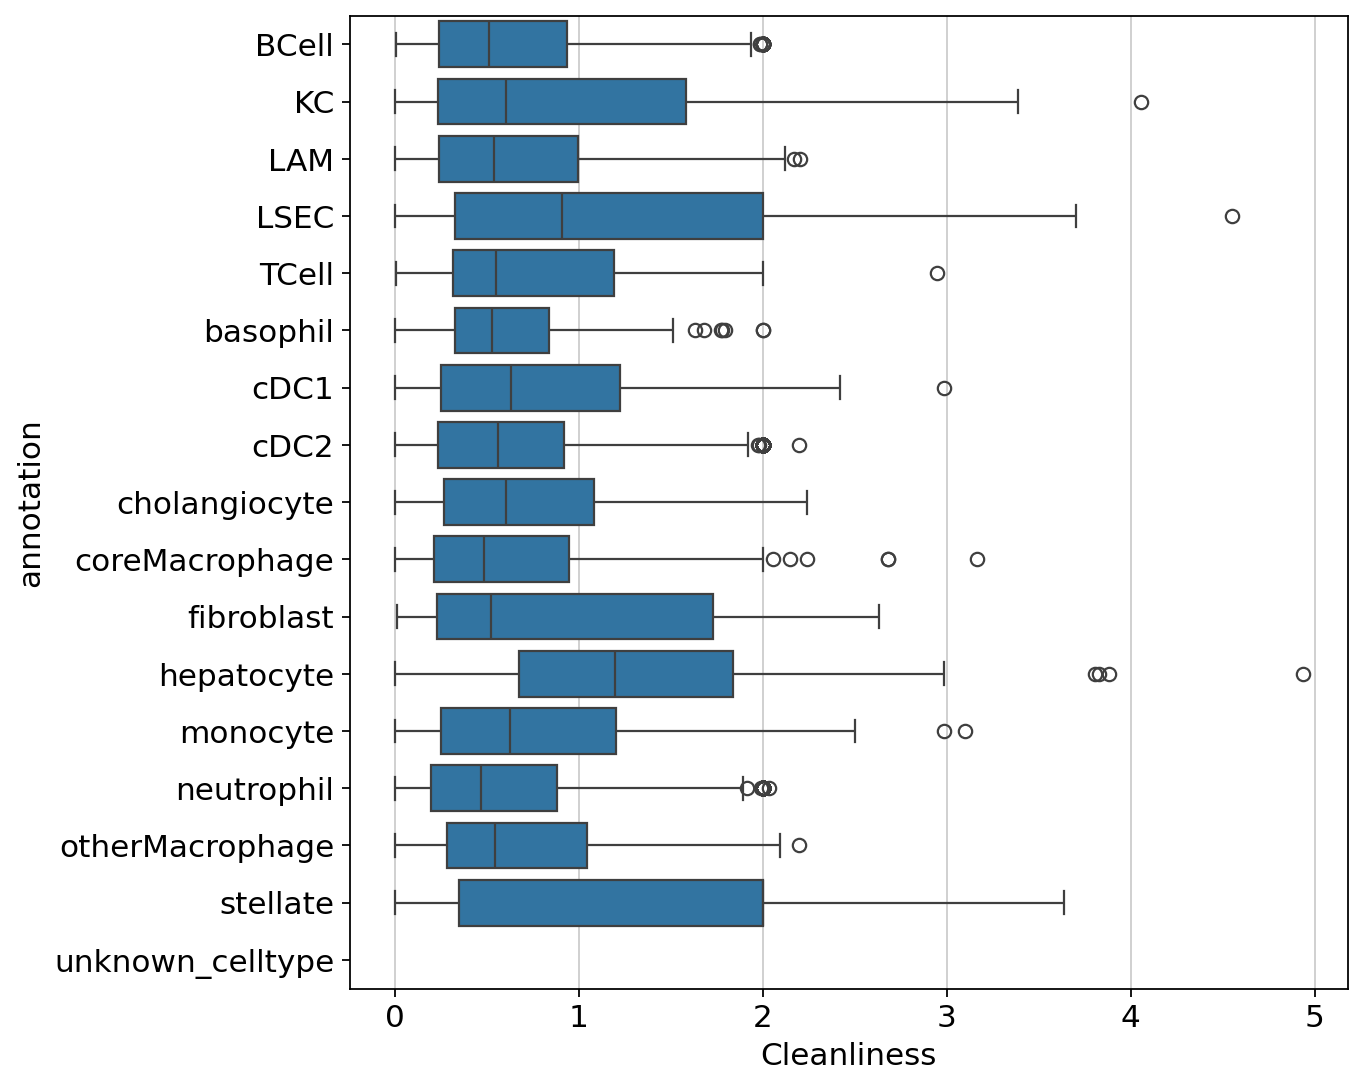

In [9]:
sns.boxplot(y="annotation", x="Cleanliness",
            # Filter data to scores between -25 and 25
            data=sdata[table_layer].obs[(sdata[table_layer].obs["Cleanliness"] < 5) & 
                                        (sdata[table_layer].obs["Cleanliness"] > 0)])
            #data=sdata[table_layer].obs)